In [1]:
print(2)

2


✓ Cargado: Pinar_del_Río
✓ Cargado: Holguín
✓ Cargado: Las_Tunas
✓ Cargado: Villa_Clara
✓ Cargado: Artemisa
✓ Cargado: Camagüey
✓ Cargado: Santiago_de_Cuba
✓ Cargado: La_Habana
✓ Cargado: Mayabeque
📊 Analizando autocorrelación para: Pinar_del_Río


<Figure size 720x360 with 0 Axes>

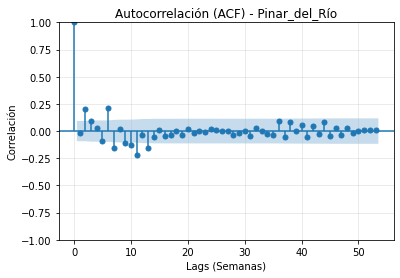

📊 Analizando autocorrelación para: Holguín


<Figure size 720x360 with 0 Axes>

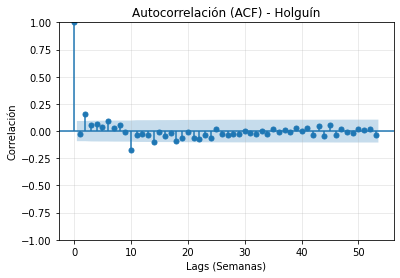

📊 Analizando autocorrelación para: Las_Tunas


<Figure size 720x360 with 0 Axes>

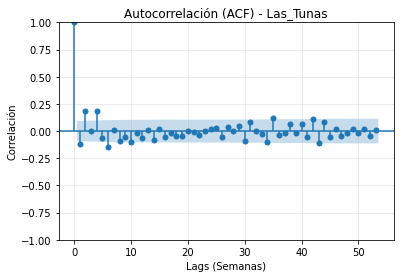

📊 Analizando autocorrelación para: Villa_Clara


<Figure size 720x360 with 0 Axes>

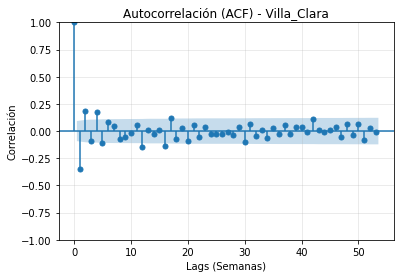

📊 Analizando autocorrelación para: Artemisa


<Figure size 720x360 with 0 Axes>

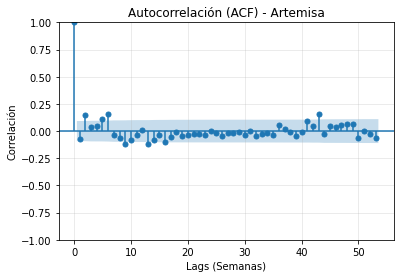

📊 Analizando autocorrelación para: Camagüey


<Figure size 720x360 with 0 Axes>

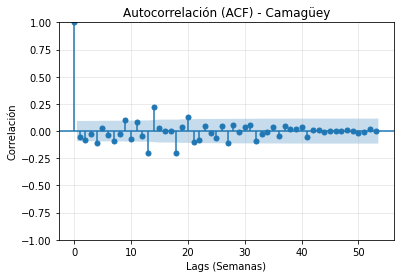

📊 Analizando autocorrelación para: Santiago_de_Cuba


<Figure size 720x360 with 0 Axes>

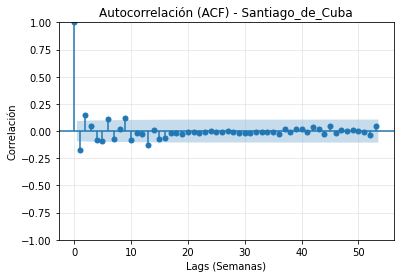

📊 Analizando autocorrelación para: La_Habana


<Figure size 720x360 with 0 Axes>

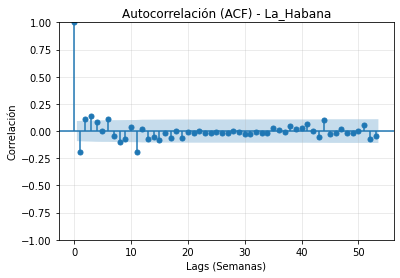

📊 Analizando autocorrelación para: Mayabeque


<Figure size 720x360 with 0 Axes>

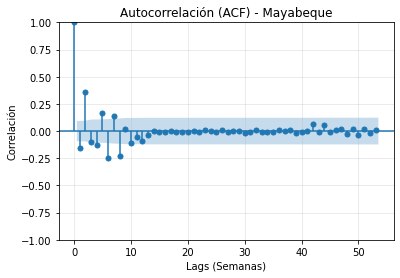

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
import os 

carpeta = 'dataframes_con_lags'

dataframes_dict = {}

for archivo in os.listdir(carpeta):
    if archivo.endswith('.csv'):

        nombre = os.path.splitext(archivo)[0]
        
        ruta_completa = os.path.join(carpeta, archivo)
        dataframes_dict[nombre] = pd.read_csv(ruta_completa)
        
        print(f"✓ Cargado: {nombre}")
            


def graficar_ccf(serie1, serie2, nombre_serie1, nombre_serie2, max_lag=52):
    """
    Calcula y grafica la Función de Correlación Cruzada (CCF).
    
    Args:
        serie1 (pd.Series): Serie de tiempo principal (ej. Casos de Dengue).
        serie2 (pd.Series): Serie de tiempo secundaria (ej. Precipitaciones).
        nombre_serie1 (str): Nombre para la etiqueta de la serie 1.
        nombre_serie2 (str): Nombre para la etiqueta de la serie 2.
        max_lag (int): Número máximo de semanas de retardo a analizar.
    """
    df_temp = pd.DataFrame({f'{nombre_serie1}': serie1, f'{nombre_serie2}': serie2}).dropna()
    s1 = df_temp[f'{nombre_serie1}']
    s2 = df_temp[f'{nombre_serie2}']
    
    # El orden importa: ccf(x, y) mide cómo x se correlaciona con y en lags de x
    ccf_values = ccf(s2, s1, adjusted=False)[:max_lag+1]
    
    lags = np.arange(0, len(ccf_values))
    
    # Calcular las bandas de confianza
    n = len(s1)
    conf_level = 1.96 / np.sqrt(n)
    
    plt.figure(figsize=(12, 6))
    plt.stem(lags, ccf_values, basefmt=" ")
    plt.axhline(0, color='gray', linestyle='--')
    plt.axhline(conf_level, color='blue', linestyle='--', label='Banda de Confianza (95%)')
    plt.axhline(-conf_level, color='blue', linestyle='--')
    
    max_corr_idx = np.argmax(np.abs(ccf_values))
    max_corr_lag = lags[max_corr_idx]
    max_corr_value = ccf_values[max_corr_idx]
    
    plt.plot(max_corr_lag, max_corr_value, 'ro') # Punto rojo en el máximo
    plt.annotate(f'Lag: {max_corr_lag}S, Corr: {max_corr_value:.2f}',
                 xy=(max_corr_lag, max_corr_value),
                 xytext=(max_corr_lag + 1, max_corr_value),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

    plt.title(f'Función de Correlación Cruzada: {nombre_serie1} vs. {nombre_serie2}', fontsize=14)
    plt.xlabel(f'Retardo (Lag) en semanas de {nombre_serie2}')
    plt.ylabel('Correlación')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


from statsmodels.graphics.tsaplots import plot_acf


for nombre_provincia, df_provincia in dataframes_dict.items():
    print(f"📊 Analizando autocorrelación para: {nombre_provincia}")
    
    serie_dengue = df_provincia['Casos_Dengue'].fillna(0)
    
    # 3. Aplicar diferenciación (diff) 
    # Esto es vital en dengue porque los casos tienen tendencia y estacionalidad
    serie_diff = serie_dengue.diff().dropna()
    
    plt.figure(figsize=(10, 5))
    plot_acf(serie_diff, lags=53, title=f"Autocorrelación (ACF) - {nombre_provincia}")
    plt.xlabel("Lags (Semanas)")
    plt.ylabel("Correlación")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Opcional: Ver los valores numéricos de los primeros lags
    # autocorr_values = [serie_diff.autocorr(lag=i) for i in range(1, 7)]
    # print(f"Lags 1-6: {autocorr_values}")
    
    

# for provincia in provincias:
#     df_provincia = df_combinado[df_combinado['Provincias'] == provincia].copy()
#     df_provincia = df_provincia.sort_index()

#     serie_dengue = df_provincia['Casos_Dengue']
    
#     if True:#provincia == "Matanzas":
#         print("⚠️ Aplicando diff() a ",provincia)
#         # Es fundamental que si aplicas diff a una, 
#         # las variables climáticas correspondan a los mismos periodos.
#         # Por eso creamos un dataframe temporal para alinear tras el diff
#         df_temp = df_provincia[['Casos_Dengue'] + variables_climaticas].diff().dropna()
#         serie_dengue = df_temp['Casos_Dengue']
#     # else:
#     #     print(provincia)
#     #     df_temp = df_provincia[['Casos_Dengue'] + variables_climaticas]
#     #     serie_dengue = df_temp['Casos_Dengue']
        
#     for variable in variables_climaticas:
#         # Llamar a la función para graficar la CCF
#         graficar_ccf(
#             serie1=serie_dengue,
#             serie2=df_temp[variable],
#             nombre_serie1='Casos de Dengue',
#             nombre_serie2=variable,
#             max_lag=26 # Analizar hasta 20 semanas de retardo
#         )

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf

def encontrar_lags_AUTOCORR_significativos(serie, nombre_provincia, max_lag=20, alpha=0.05):
    """
    Identifica qué semanas del pasado del dengue influyen significativamente 
    en el presente, usando diferenciación para asegurar estacionariedad.
    """

    dy = serie.diff().dropna()
    
    acf_values = ccf(dy, dy, adjusted=False)[:max_lag+1]
    
    lags_validados = []

    for lag in range(1, len(acf_values)):
        r_val = acf_values[lag]
        
        y_presente = dy.iloc[lag:]
        y_pasado = dy.shift(lag).dropna()
        
        common_idx = y_presente.index.intersection(y_pasado.index)
        
        if len(common_idx) > 10: # Mínimo de datos para que el p-valor sea confiable
            _, p_val = pearsonr(y_presente.loc[common_idx], y_pasado.loc[common_idx])
            
            # Filtro: correlación mínima de 0.05 y p-valor significativo
            if abs(r_val) >= 0.05 and p_val < alpha:
                lags_validados.append({
                    'provincia': nombre_provincia,
                    'lag': lag,
                    'correlacion': r_val,
                    'p_valor': p_val
                })
                
    return lags_validados


print(f"{'Provincia':<20} | {'Lags de Dengue Validados (p < 0.05)'}")
print("-" * 65)

lags_autocorr_finales = {}

for nombre, df_provincia in dataframes_dict.items():

    serie_dengue = df_provincia['Casos_Dengue'].fillna(0)
    
    lags_encontrados = encontrar_lags_AUTOCORR_significativos(serie_dengue, nombre)
    
    if lags_encontrados:
        lags_autocorr_finales[nombre] = [l['lag'] for l in lags_encontrados]
        
        lags_str = ", ".join([f"Sem {l['lag']} (r:{l['correlacion']:.2f})" for l in lags_encontrados])
        print(f"{nombre:<20} | {lags_str}")
    else:
        print(f"{nombre:<20} | No se hallaron lags significativos")

Provincia            | Lags de Dengue Validados (p < 0.05)
-----------------------------------------------------------------
Pinar_del_Río        | Sem 2 (r:0.20), Sem 3 (r:0.09), Sem 5 (r:-0.09), Sem 6 (r:0.21), Sem 7 (r:-0.16), Sem 9 (r:-0.11), Sem 10 (r:-0.13), Sem 11 (r:-0.22), Sem 13 (r:-0.15)
Holguín              | Sem 2 (r:0.15), Sem 10 (r:-0.18), Sem 14 (r:-0.10), Sem 18 (r:-0.10)
Las_Tunas            | Sem 1 (r:-0.12), Sem 2 (r:0.18), Sem 4 (r:0.18), Sem 6 (r:-0.15), Sem 10 (r:-0.10), Sem 14 (r:-0.08)
Villa_Clara          | Sem 1 (r:-0.34), Sem 2 (r:0.18), Sem 4 (r:0.18), Sem 5 (r:-0.11), Sem 12 (r:-0.15), Sem 16 (r:-0.14), Sem 17 (r:0.12), Sem 20 (r:-0.09)
Artemisa             | Sem 2 (r:0.15), Sem 5 (r:0.11), Sem 6 (r:0.16), Sem 9 (r:-0.12), Sem 13 (r:-0.12), Sem 14 (r:-0.08), Sem 16 (r:-0.10)
Camagüey             | Sem 4 (r:-0.11), Sem 7 (r:-0.09), Sem 9 (r:0.10), Sem 11 (r:0.08), Sem 13 (r:-0.21), Sem 14 (r:0.22), Sem 18 (r:-0.20), Sem 20 (r:0.13)
Santiago_de_Cuba     | Se

⚠️ Saltando Pinar_del_Río: ya existe en el diccionario
✓ Cargado: Ciego_de_Ávila
✓ Cargado: Matanzas
✓ Cargado: Cienfuegos
✓ Cargado: Guantánamo
⚠️ Saltando Holguín: ya existe en el diccionario
⚠️ Saltando Las_Tunas: ya existe en el diccionario
✓ Cargado: Isla_de_la_Juventud
⚠️ Saltando Villa_Clara: ya existe en el diccionario
⚠️ Saltando Artemisa: ya existe en el diccionario
⚠️ Saltando Camagüey: ya existe en el diccionario
⚠️ Saltando Santiago_de_Cuba: ya existe en el diccionario
✓ Cargado: Sancti_Spíritus
✓ Cargado: Granma
⚠️ Saltando La_Habana: ya existe en el diccionario
⚠️ Saltando Mayabeque: ya existe en el diccionario
📊 Analizando autocorrelación para: Pinar_del_Río


<Figure size 720x360 with 0 Axes>

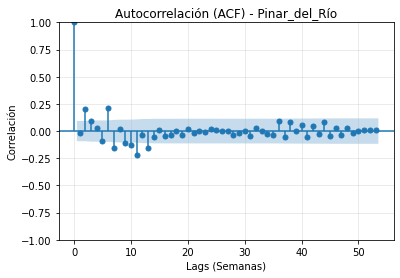

📊 Analizando autocorrelación para: Holguín


<Figure size 720x360 with 0 Axes>

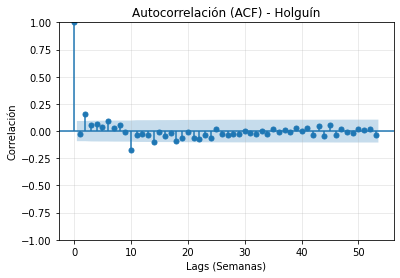

📊 Analizando autocorrelación para: Las_Tunas


<Figure size 720x360 with 0 Axes>

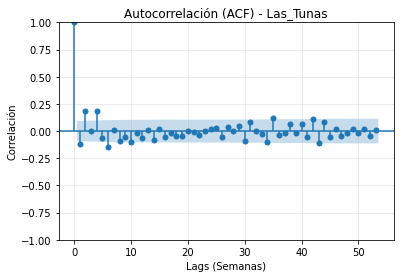

📊 Analizando autocorrelación para: Villa_Clara


<Figure size 720x360 with 0 Axes>

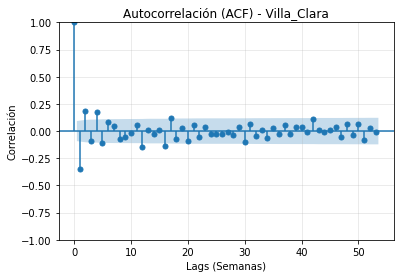

📊 Analizando autocorrelación para: Artemisa


<Figure size 720x360 with 0 Axes>

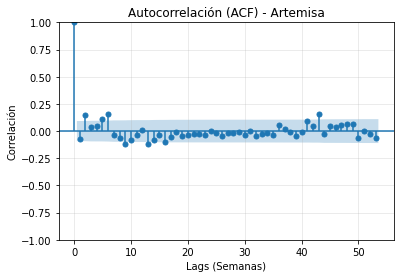

📊 Analizando autocorrelación para: Camagüey


<Figure size 720x360 with 0 Axes>

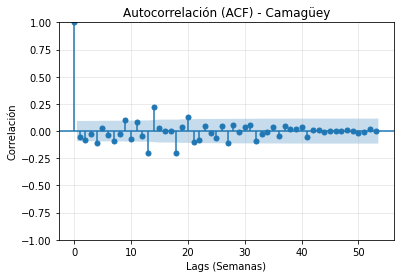

📊 Analizando autocorrelación para: Santiago_de_Cuba


<Figure size 720x360 with 0 Axes>

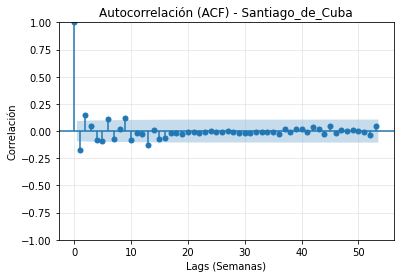

📊 Analizando autocorrelación para: La_Habana


<Figure size 720x360 with 0 Axes>

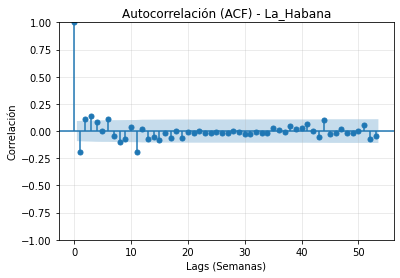

📊 Analizando autocorrelación para: Mayabeque


<Figure size 720x360 with 0 Axes>

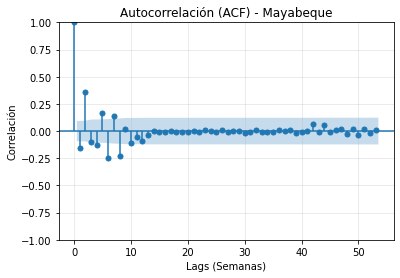

📊 Analizando autocorrelación para: Ciego_de_Ávila


<Figure size 720x360 with 0 Axes>

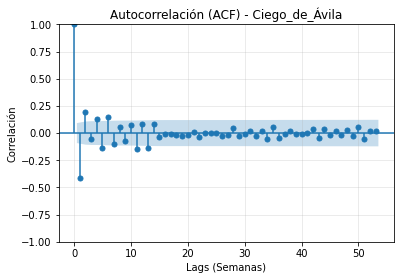

📊 Analizando autocorrelación para: Matanzas


<Figure size 720x360 with 0 Axes>

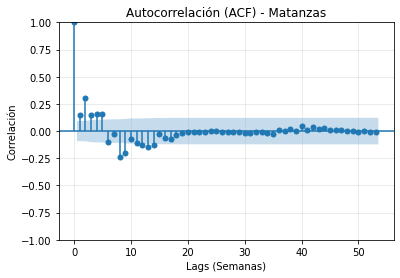

📊 Analizando autocorrelación para: Cienfuegos


<Figure size 720x360 with 0 Axes>

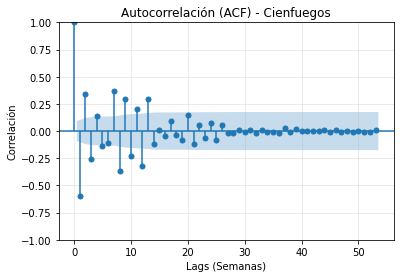

📊 Analizando autocorrelación para: Guantánamo


<Figure size 720x360 with 0 Axes>

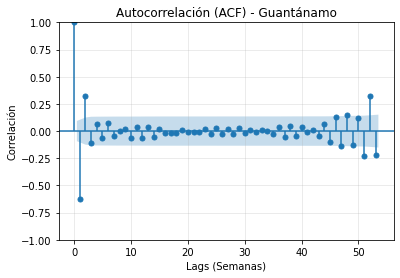

📊 Analizando autocorrelación para: Isla_de_la_Juventud


<Figure size 720x360 with 0 Axes>

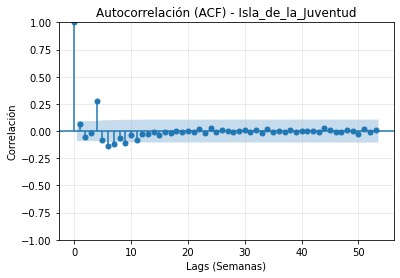

📊 Analizando autocorrelación para: Sancti_Spíritus


<Figure size 720x360 with 0 Axes>

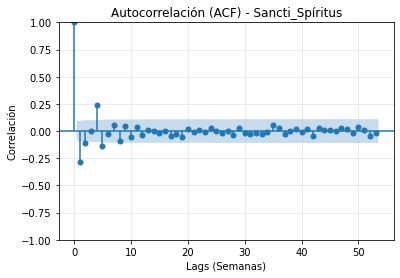

📊 Analizando autocorrelación para: Granma


<Figure size 720x360 with 0 Axes>

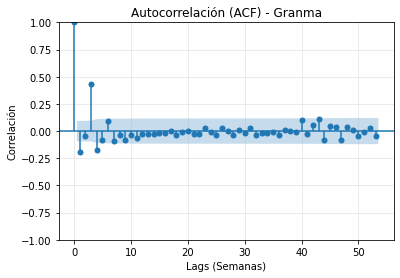

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
import os 

carpeta = 'dataframes_provincias'
            
for archivo in os.listdir(carpeta):
    if archivo.endswith('.csv'):
        nombre = os.path.splitext(archivo)[0]
        
        if nombre not in dataframes_dict:
            ruta_completa = os.path.join(carpeta, archivo)
            dataframes_dict[nombre] = pd.read_csv(ruta_completa)
            print(f"✓ Cargado: {nombre}")
        else:
            print(f"⚠️ Saltando {nombre}: ya existe en el diccionario")
            

def graficar_ccf(serie1, serie2, nombre_serie1, nombre_serie2, max_lag=52):
    """
    Calcula y grafica la Función de Correlación Cruzada (CCF).
    
    Args:
        serie1 (pd.Series): Serie de tiempo principal (ej. Casos de Dengue).
        serie2 (pd.Series): Serie de tiempo secundaria (ej. Precipitaciones).
        nombre_serie1 (str): Nombre para la etiqueta de la serie 1.
        nombre_serie2 (str): Nombre para la etiqueta de la serie 2.
        max_lag (int): Número máximo de semanas de retardo a analizar.
    """
    df_temp = pd.DataFrame({f'{nombre_serie1}': serie1, f'{nombre_serie2}': serie2}).dropna()
    s1 = df_temp[f'{nombre_serie1}']
    s2 = df_temp[f'{nombre_serie2}']
    
    # El orden importa: ccf(x, y) mide cómo x se correlaciona con y en lags de x
    ccf_values = ccf(s2, s1, adjusted=False)[:max_lag+1]
    
    lags = np.arange(0, len(ccf_values))
    
    # Calcular las bandas de confianza
    n = len(s1)
    conf_level = 1.96 / np.sqrt(n)
    
    plt.figure(figsize=(12, 6))
    plt.stem(lags, ccf_values, basefmt=" ")
    plt.axhline(0, color='gray', linestyle='--')
    plt.axhline(conf_level, color='blue', linestyle='--', label='Banda de Confianza (95%)')
    plt.axhline(-conf_level, color='blue', linestyle='--')
    
    max_corr_idx = np.argmax(np.abs(ccf_values))
    max_corr_lag = lags[max_corr_idx]
    max_corr_value = ccf_values[max_corr_idx]
    
    plt.plot(max_corr_lag, max_corr_value, 'ro') # Punto rojo en el máximo
    plt.annotate(f'Lag: {max_corr_lag}S, Corr: {max_corr_value:.2f}',
                 xy=(max_corr_lag, max_corr_value),
                 xytext=(max_corr_lag + 1, max_corr_value),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

    plt.title(f'Función de Correlación Cruzada: {nombre_serie1} vs. {nombre_serie2}', fontsize=14)
    plt.xlabel(f'Retardo (Lag) en semanas de {nombre_serie2}')
    plt.ylabel('Correlación')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


from statsmodels.graphics.tsaplots import plot_acf


for nombre_provincia, df_provincia in dataframes_dict.items():
    print(f"📊 Analizando autocorrelación para: {nombre_provincia}")
    
    serie_dengue = df_provincia['Casos_Dengue'].fillna(0)
    
    # 3. Aplicar diferenciación (diff) 
    # Esto es vital en dengue porque los casos tienen tendencia y estacionalidad
    serie_diff = serie_dengue.diff().dropna()
    
    plt.figure(figsize=(10, 5))
    plot_acf(serie_diff, lags=53, title=f"Autocorrelación (ACF) - {nombre_provincia}")
    plt.xlabel("Lags (Semanas)")
    plt.ylabel("Correlación")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Opcional: Ver los valores numéricos de los primeros lags
    # autocorr_values = [serie_diff.autocorr(lag=i) for i in range(1, 7)]
    # print(f"Lags 1-6: {autocorr_values}")
    
    

# for provincia in provincias:
#     df_provincia = df_combinado[df_combinado['Provincias'] == provincia].copy()
#     df_provincia = df_provincia.sort_index()

#     serie_dengue = df_provincia['Casos_Dengue']
    
#     if True:#provincia == "Matanzas":
#         print("⚠️ Aplicando diff() a ",provincia)
#         # Es fundamental que si aplicas diff a una, 
#         # las variables climáticas correspondan a los mismos periodos.
#         # Por eso creamos un dataframe temporal para alinear tras el diff
#         df_temp = df_provincia[['Casos_Dengue'] + variables_climaticas].diff().dropna()
#         serie_dengue = df_temp['Casos_Dengue']
#     # else:
#     #     print(provincia)
#     #     df_temp = df_provincia[['Casos_Dengue'] + variables_climaticas]
#     #     serie_dengue = df_temp['Casos_Dengue']
        
#     for variable in variables_climaticas:
#         # Llamar a la función para graficar la CCF
#         graficar_ccf(
#             serie1=serie_dengue,
#             serie2=df_temp[variable],
#             nombre_serie1='Casos de Dengue',
#             nombre_serie2=variable,
#             max_lag=26 # Analizar hasta 20 semanas de retardo
#         )

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf

def encontrar_lags_AUTOCORR_significativos(serie, nombre_provincia, max_lag=20, alpha=0.05):
    """
    Identifica qué semanas del pasado del dengue influyen significativamente 
    en el presente, usando diferenciación para asegurar estacionariedad.
    """

    dy = serie.diff().dropna()
    
    acf_values = ccf(dy, dy, adjusted=False)[:max_lag+1]
    
    lags_validados = []

    for lag in range(1, len(acf_values)):
        r_val = acf_values[lag]
        
        y_presente = dy.iloc[lag:]
        y_pasado = dy.shift(lag).dropna()
        
        common_idx = y_presente.index.intersection(y_pasado.index)
        
        if len(common_idx) > 10: # Mínimo de datos para que el p-valor sea confiable
            _, p_val = pearsonr(y_presente.loc[common_idx], y_pasado.loc[common_idx])
            
            # Filtro: correlación mínima de 0.05 y p-valor significativo
            if abs(r_val) >= 0.05 and p_val < alpha:
                lags_validados.append({
                    'provincia': nombre_provincia,
                    'lag': lag,
                    'correlacion': r_val,
                    'p_valor': p_val
                })
                
    return lags_validados


print(f"{'Provincia':<20} | {'Lags de Dengue Validados (p < 0.05)'}")
print("-" * 65)

lags_autocorr_finales = {}

for nombre, df_provincia in dataframes_dict.items():

    serie_dengue = df_provincia['Casos_Dengue'].fillna(0)
    
    lags_encontrados = encontrar_lags_AUTOCORR_significativos(serie_dengue, nombre)
    
    if lags_encontrados:
        lags_autocorr_finales[nombre] = [l['lag'] for l in lags_encontrados]
        
        lags_str = ", ".join([f"Sem {l['lag']} (r:{l['correlacion']:.2f})" for l in lags_encontrados])
        print(f"{nombre:<20} | {lags_str}")
    else:
        print(f"{nombre:<20} | No se hallaron lags significativos")

Provincia            | Lags de Dengue Validados (p < 0.05)
-----------------------------------------------------------------
Pinar_del_Río        | Sem 2 (r:0.20), Sem 3 (r:0.09), Sem 5 (r:-0.09), Sem 6 (r:0.21), Sem 7 (r:-0.16), Sem 9 (r:-0.11), Sem 10 (r:-0.13), Sem 11 (r:-0.22), Sem 13 (r:-0.15)
Holguín              | Sem 2 (r:0.15), Sem 10 (r:-0.18), Sem 14 (r:-0.10), Sem 18 (r:-0.10)
Las_Tunas            | Sem 1 (r:-0.12), Sem 2 (r:0.18), Sem 4 (r:0.18), Sem 6 (r:-0.15), Sem 10 (r:-0.10), Sem 14 (r:-0.08)
Villa_Clara          | Sem 1 (r:-0.34), Sem 2 (r:0.18), Sem 4 (r:0.18), Sem 5 (r:-0.11), Sem 12 (r:-0.15), Sem 16 (r:-0.14), Sem 17 (r:0.12), Sem 20 (r:-0.09)
Artemisa             | Sem 2 (r:0.15), Sem 5 (r:0.11), Sem 6 (r:0.16), Sem 9 (r:-0.12), Sem 13 (r:-0.12), Sem 14 (r:-0.08), Sem 16 (r:-0.10)
Camagüey             | Sem 4 (r:-0.11), Sem 7 (r:-0.09), Sem 9 (r:0.10), Sem 11 (r:0.08), Sem 13 (r:-0.21), Sem 14 (r:0.22), Sem 18 (r:-0.20), Sem 20 (r:0.13)
Santiago_de_Cuba     | Se